## Customer Churn Analysis – Telco
## Objective of the Analysis

The analysis will notably make it possible to:
    identify the customer profiles most likely to churn

   * understand how long customers generally remain active

   * analyze the impact of financial and contractual factors

   * identify the variables most associated with churn

   * propose concrete actions to improve customer retention

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

CustomerID : Unique identifier of the customer.

Gender : Gender of the customer (male or female).

SeniorCitizen : Indicates whether the customer is a senior citizen (1 = yes, 0 = no).

Partner : Indicates whether the customer is in a relationship (Yes / No).

Dependents : Indicates whether the customer has dependents (children or others).

Tenure : Customer tenure in number of months since subscription.

PhoneService : Indicates whether the customer has a phone service.

MultipleLines : Indicates whether the customer has multiple phone lines.

InternetService : Type of internet service (DSL, fiber optic, or none).

OnlineSecurity : Indicates whether the customer has an online security service.

DeviceProtection : Indicates whether the customer has protection for their devices.

TechSupport : Indicates whether the customer has access to technical support.

StreamingTV : Indicates whether the customer uses a TV streaming service.

StreamingMovies : Indicates whether the customer uses a movie streaming service.

Contract : Type of contract (monthly, 1 year, 2 years).

PaperlessBilling : Indicates whether billing is electronic (paperless).

PaymentMethod : Payment method used by the customer.

MonthlyCharges : Amount paid by the customer each month.

TotalCharges : Total amount paid by the customer since the beginning of the subscription.

Churn : Indicates whether the customer has unsubscribed (Yes) or remained (No).



## Data Cleaning

Before the analysis, some cleaning operations are necessary.

* The **TotalCharges** variable is converted into a numeric value because some observations contain non-numeric values.

* Missing values appear after the conversion. These rows are removed because they represent a very small proportion of the data and do not allow correct analysis of customers' total spending.

* Duplicates are checked in order to avoid counting the same customer multiple times.


In [2]:
df = pd.read_csv("telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [8]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [9]:
df = df.dropna()
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Analysis of the Profile of Customers Who Churn

In [11]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

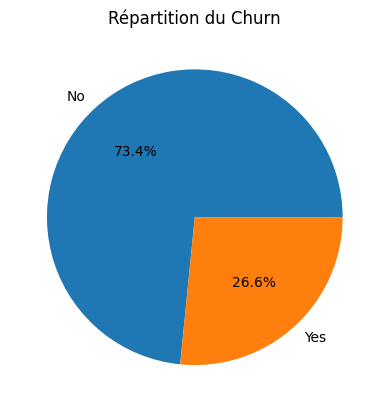

In [12]:
counts = df['Churn'].value_counts()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title('Répartition du Churn')
plt.show()

### Churn Distribution

This chart shows the proportion of customers who remain on the platform and those who leave the service.

We observe that **73.4% of customers keep their subscription**, while **26.6% unsubscribe**.

Although the majority of customers stay, a churn rate of nearly **27%** remains significant. It is therefore important to identify the factors that explain these departures in order to improve customer retention.


In [13]:
senior_churn = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')
senior_churn

Churn,No,Yes
SeniorCitizen,,
0,0.763497,0.236503
1,0.583187,0.416813


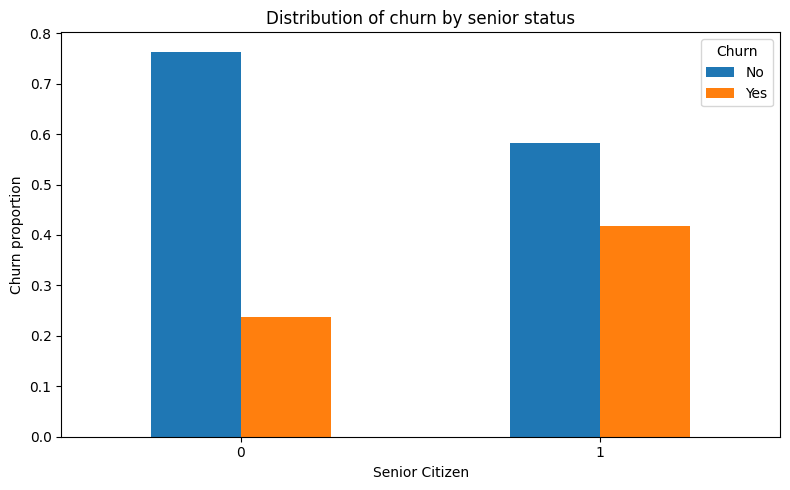

In [14]:
senior_churn.plot(kind='bar', figsize=(8,5))

plt.xlabel('Senior Citizen')
plt.ylabel('Churn proportion')
plt.title('Distribution of churn by senior status')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
senior_table = pd.crosstab(df['SeniorCitizen'], df['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(senior_table)
print(f"p-value: {p}")

p-value: 2.4792557203954705e-36


### Impact of Senior Status on Churn

The analysis shows that senior customers have a significantly higher churn rate than other customers.

Indeed, about 42% of senior customers leave the service, compared to only 23% of non-senior customers.

The chi-square test confirms that this relationship is statistically significant (p-value < 0.05).

These results suggest that senior customers represent a particularly at-risk segment and may require specific retention strategies.


In [16]:
gender_churn = pd.crosstab(df['gender'], df['Churn'], normalize='index')
gender_churn

Churn,No,Yes
gender,,
Female,0.730405,0.269595
Male,0.737954,0.262046


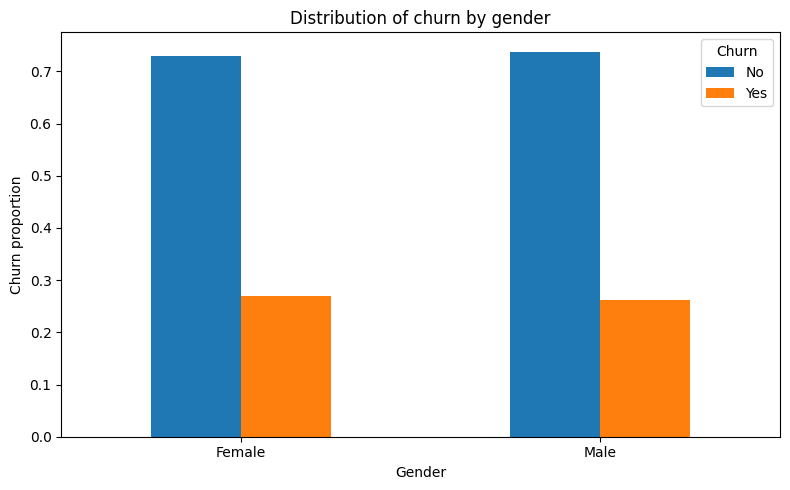

In [17]:
gender_churn.plot(kind='bar', figsize=(8,5))

plt.xlabel('Gender')
plt.ylabel('Churn proportion')
plt.title('Distribution of churn by gender')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Impact of Gender on Churn

The analysis shows that the churn rate is very similar between men and women.

Women have a churn rate of about 27%, while men have a rate of about 26%.

The chi-square test confirms that this difference is not statistically significant (p-value = 0.49).

These results suggest that gender is not an important factor in customers’ decision to leave the service.

In [18]:
gender_table = pd.crosstab(df['gender'], df['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(gender_table)
print(f"p-value: {p}")

p-value: 0.4904884707065509


In [19]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [20]:
chi2, p , dof, expected = stats.chi2_contingency(contract_churn)
print(f'p-value: {p}, chi:{chi2}')

p-value: 7.326182186265472e-257, chi:1179.5458287339445


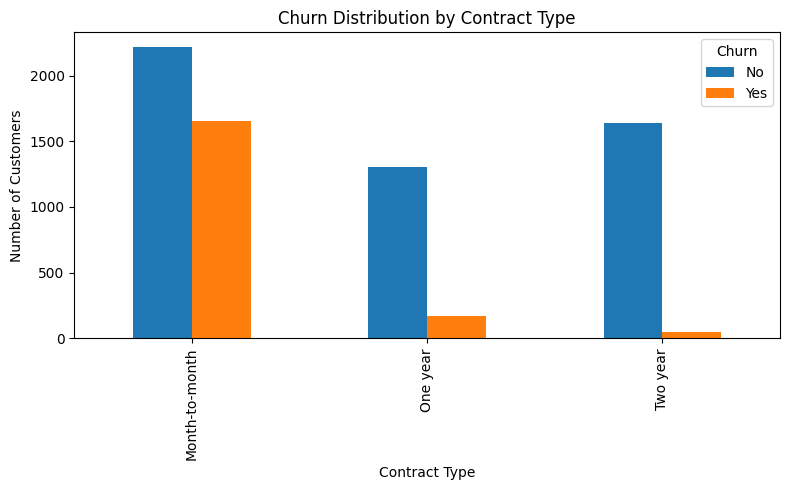

In [21]:
contract_churn.plot(kind='bar', figsize=(8,5))
plt.xlabel('Contract Type')
plt.ylabel("Number of Customers")
plt.title("Churn Distribution by Contract Type")
plt.tight_layout()
plt.show()

### Impact of Contract Type on Churn

The contingency table shows that customers with a "Month-to-month" contract have a much higher churn rate than those with one- or two-year contracts.

The Chi² test gives an extremely low p-value (p < 0.05), indicating that the relationship between contract type and churn is statistically significant.

This means that contract type is an important factor in customers’ decision to leave the service.

Business Interpretation:

Monthly contracts offer more flexibility, allowing customers to leave the company easily. In contrast, longer contracts encourage loyalty.

The company could therefore reduce churn by encouraging customers to subscribe to longer contracts (discounts, benefits, etc.).


In [22]:
bins = [0, 25, 50, 75, 100, 125]
labels = ['0-25', '25-50', '50-75', '75-100', '100-125']
df['MonthlyCharges_bins'] = pd.cut(df['MonthlyCharges'], bins=bins, labels=labels, right=False)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyCharges_bins
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,25-50
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,50-75
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,50-75
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50-75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,75-100
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,100-125
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,25-50
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,50-75


In [23]:
monthlyCharges_churn = pd.crosstab(df['MonthlyCharges_bins'], df['Churn'])
monthlyCharges_churn

Churn,No,Yes
MonthlyCharges_bins,,
0-25,1258,127
25-50,669,234
50-75,1193,424
75-100,1392,827
100-125,651,257


In [24]:
monthlyCharges_churn_rate = pd.crosstab(df['MonthlyCharges_bins'], df['Churn'], normalize='index')
monthlyCharges_churn_rate

Churn,No,Yes
MonthlyCharges_bins,,
0-25,0.908303,0.091697
25-50,0.740864,0.259136
50-75,0.737786,0.262214
75-100,0.627310,0.372690
100-125,0.716960,0.283040


In [25]:
chi2, p , dof, expected = stats.chi2_contingency(monthlyCharges_churn)
print(f'p-value: {p}, chi:{chi2}')

p-value: 8.820734867502674e-74, chi:346.75080431108364


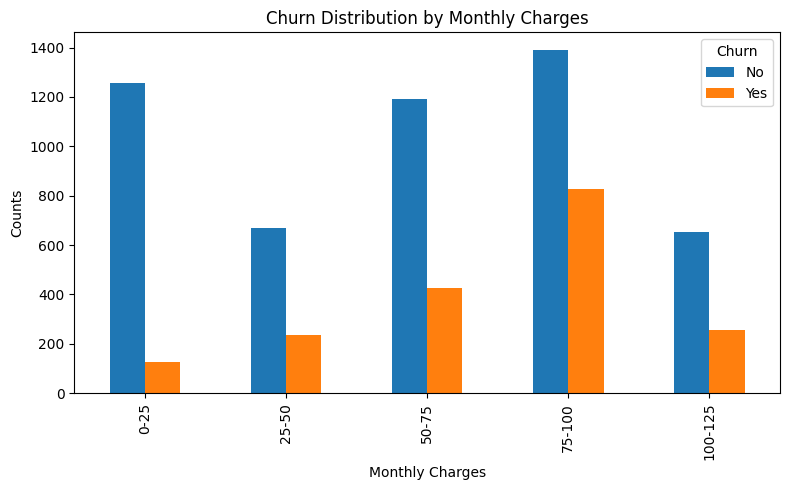

In [26]:
monthlyCharges_churn.plot(kind='bar', figsize=(8,5))
plt.xlabel('Monthly Charges')
plt.ylabel('Counts')
plt.title('Churn Distribution by Monthly Charges')
plt.tight_layout()
plt.show()

### Impact of Monthly Charges on Churn

The analysis shows that customers with higher monthly charges have a higher churn rate.

The Chi² test confirms that the relationship between monthly charges and churn is statistically significant (p-value < 0.05).

Business Interpretation:

Customers paying higher amounts may be more price-sensitive and therefore more likely to leave the service. This may also indicate that certain premium offers or services do not fully meet customer expectations.

The company could analyze the satisfaction of customers with high charges more closely or offer better-suited plans to reduce churn.

In [27]:
bins = [
    0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
        55, 60, 65, 70, 75]
labels = [
    '0-5', '5-10', '10-15', '15-20', '20-25', 
    '25-30', '30-35', '35-40', '40-45', '45-50',
    '50-55', '55-60', '60-65', '65-70', '70-75'
]

df['tenure_bins'] = pd.cut(df['tenure'], bins=bins, labels=labels)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyCharges_bins,tenure_bins
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,25-50,0-5
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,50-75,30-35
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,50-75,0-5
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-50,40-45
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50-75,0-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,75-100,20-25
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,100-125,70-75
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,25-50,10-15
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,50-75,0-5


In [28]:
tenure_churn = pd.crosstab(df['tenure_bins'], df['Churn'])
tenure_churn 

Churn,No,Yes
tenure_bins,,
0-5,616,744
5-10,375,224
10-15,332,168
15-20,293,115
20-25,308,103
25-30,281,71
30-35,275,76
35-40,229,65
40-45,257,55


In [29]:
tenure_churn_rate = pd.crosstab(df['tenure_bins'], df['Churn'], normalize='index')
tenure_churn_rate

Churn,No,Yes
tenure_bins,,
0-5,0.452941,0.547059
5-10,0.626043,0.373957
10-15,0.664000,0.336000
15-20,0.718137,0.281863
20-25,0.749392,0.250608
25-30,0.798295,0.201705
30-35,0.783476,0.216524
35-40,0.778912,0.221088
40-45,0.823718,0.176282


In [30]:
chi2, p , dof, expected = stats.chi2_contingency(tenure_churn)
print(f'p-value: {p}, chi:{chi2}')

p-value: 2.0338591398354117e-204, chi:999.4693825484828


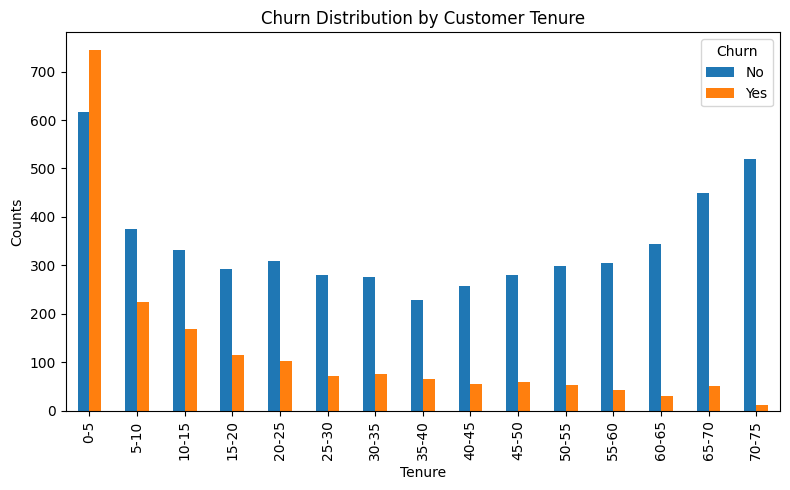

In [31]:
tenure_churn.plot(kind='bar', figsize=(8,5))
plt.xlabel('Tenure')
plt.ylabel('Counts')
plt.title("Churn Distribution by Customer Tenure")
plt.tight_layout()
plt.show()

### Impact of Customer Tenure on Churn

The analysis shows that customers with low tenure have a much higher churn rate than longer-term customers.

Customers with less than 5 months of tenure leave the service much more frequently than those who have been subscribed for several years.

The Chi² test confirms that the relationship between tenure and churn is statistically significant (p-value < 0.05).

Business Interpretation:

The first months are critical in the relationship between the customer and the company. If the initial experience is not satisfactory, customers may quickly leave the service.

The company should therefore pay special attention to new customers to improve their experience during the first months of subscription.


In [32]:
internet_service = pd.crosstab(df['InternetService'], df['Churn'])
internet_service

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [33]:
internet_service_rate = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
internet_service_rate

Churn,No,Yes
InternetService,,
DSL,0.810017,0.189983
Fiber optic,0.581072,0.418928
No,0.925658,0.074342


In [34]:
chi2, p , dof, expected = stats.chi2_contingency(internet_service)
print(f'p-value: {p}, chi:{chi2}')

p-value: 5.831198962237274e-159, chi:728.6956143058694


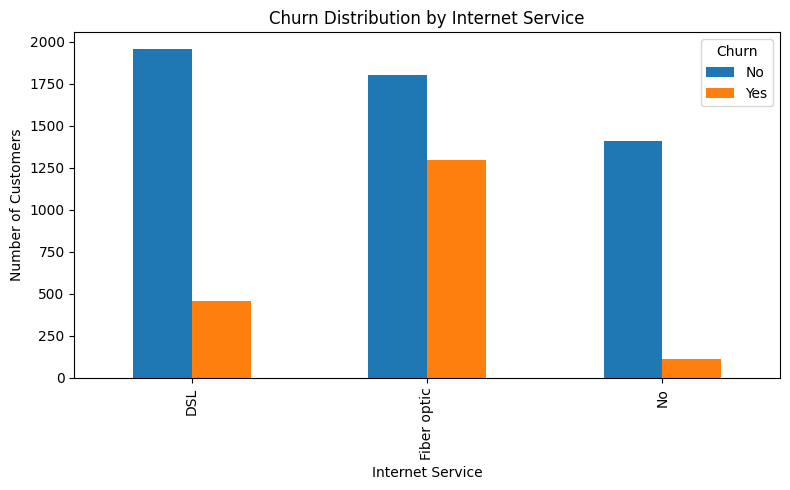

In [35]:
internet_service.plot(kind='bar', figsize=(8,5))
plt.xlabel("Internet Service")
plt.ylabel('Number of Customers')
plt.title("Churn Distribution by Internet Service")
plt.tight_layout()
plt.show()

### Impact of Internet Service Type on Churn

The analysis shows that customers using fiber optic have a much higher churn rate than those using DSL or those without internet service.

The Chi² test confirms that the relationship between internet service type and churn is statistically significant (p-value < 0.05).

Business Interpretation:

Customers using fiber optic may have higher expectations regarding service quality. If these expectations are not met or if prices are high, they may be more likely to leave the service.

The company could analyze the satisfaction of fiber optic customers more closely to identify the specific reasons for their departure.

## Studying Financial and Contractual Factors

In [36]:
monthlyCharges_intservice = pd.crosstab([df['MonthlyCharges_bins'],df['InternetService']], df['Churn'], normalize='index')
monthlyCharges_intservice

Churn                                      No       Yes
MonthlyCharges_bins InternetService                    
0-25                DSL              0.538462  0.461538
                    No               0.919019  0.080981
25-50               DSL              0.684499  0.315501
                    No               0.977011  0.022989
50-75               DSL              0.842235  0.157765
                    Fiber optic      0.420000  0.580000
75-100              DSL              0.955916  0.044084
                    Fiber optic      0.548098  0.451902
100-125             Fiber optic      0.716960  0.283040

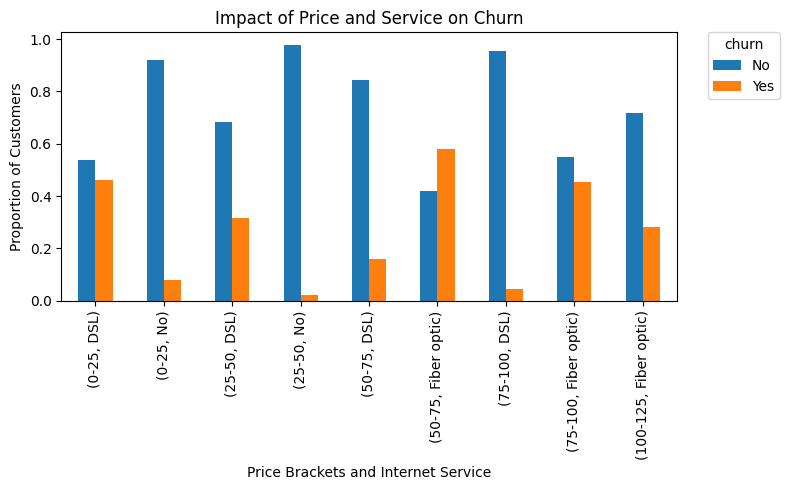

In [37]:
monthlyCharges_intservice.plot(kind='bar', figsize=(8,5))
plt.xlabel('Price Brackets and Internet Service')
plt.ylabel('Proportion of Customers')
plt.title('Impact of Price and Service on Churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


### Combined Impact of Price and Internet Service on Churn

The cross-analysis between monthly charges and internet service type shows that churn is particularly high for customers using fiber optic with high monthly charges.

For example, customers using fiber optic and paying between 50 and 75 units have a churn rate above 50%.

Conversely, customers without internet service or using DSL have much lower churn rates.

Business Interpretation:

These results suggest that fiber optic customers may be more price-sensitive or have higher expectations regarding service quality.

The company could analyze the experience of fiber optic customers in more detail to identify potential causes for their departure.


In [38]:
phone_service = pd.crosstab(df['PhoneService'], df['Churn'])
phone_service

Churn,No,Yes
PhoneService,,
No,510,170
Yes,4653,1699


In [39]:
chi2, p , dof, expected = stats.chi2_contingency(phone_service)
print(f'p-value: {p}, chi:{chi2}')

p-value: 0.34992398942431924, chi:0.8737327674431736


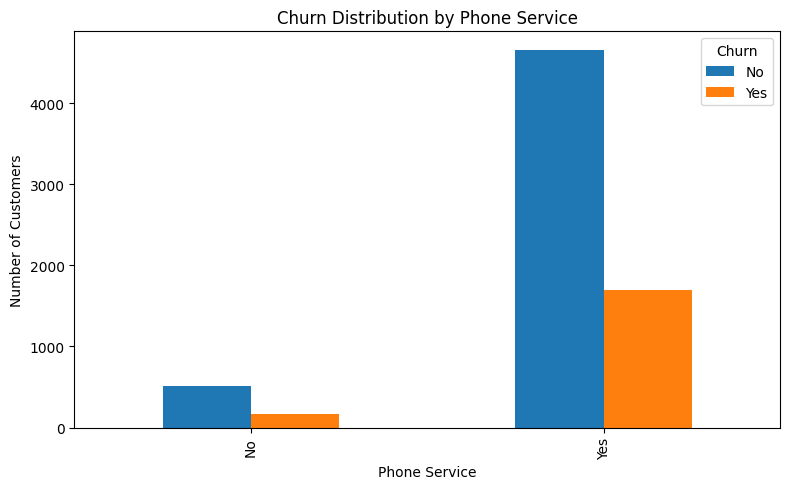

In [40]:
phone_service.plot(kind='bar', figsize=(8,5))
plt.xlabel('Phone Service')
plt.ylabel('Number of Customers')
plt.title('Churn Distribution by Phone Service')
plt.tight_layout()
plt.show()


### Impact of Phone Service on Churn

The contingency table shows the distribution of churn based on the presence or absence of a phone service.

The Chi² test gives a p-value of 0.35, which is above the 0.05 threshold. This means there is no statistically significant relationship between phone service and churn.

Interpretation:

The presence of a phone service does not seem to influence customers’ decision to leave the platform.

In [41]:
streaming_movie = pd.crosstab(df['StreamingMovies'], df['Churn'], normalize='index')
streaming_movie

Churn,No,Yes
StreamingMovies,,
No,0.662711,0.337289
No internet service,0.925658,0.074342
Yes,0.700476,0.299524


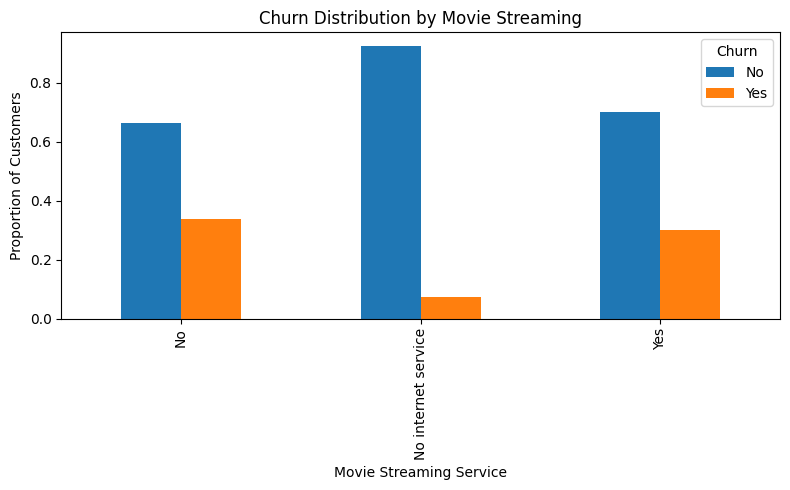

In [42]:
streaming_movie.plot(kind='bar', figsize=(8,5))
plt.xlabel('Movie Streaming Service')
plt.ylabel('Proportion of Customers')
plt.title('Churn Distribution by Movie Streaming')
plt.tight_layout()
plt.show()

### Impact of Movie Streaming Service on Churn

The analysis shows that customers with access to the movie streaming service have a churn rate relatively similar to those who do not use it.

However, customers without internet service have a much lower churn rate.

This suggests that the movie streaming service is not a major factor explaining customer churn.

In [43]:
streaming_tv = pd.crosstab(df['StreamingTV'], df['Churn'], normalize='index')
streaming_tv

Churn,No,Yes
StreamingTV,,
No,0.664649,0.335351
No internet service,0.925658,0.074342
Yes,0.698853,0.301147


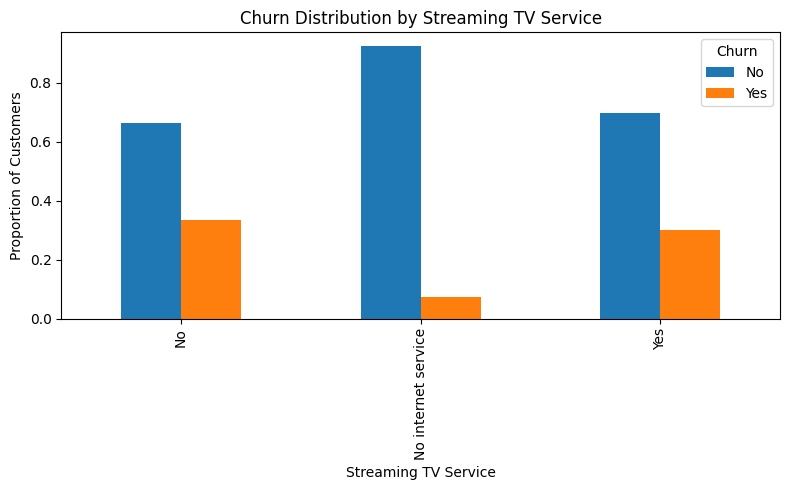

In [44]:
streaming_tv.plot(kind='bar', figsize=(8,5))
plt.xlabel('Streaming TV Service')
plt.ylabel('Proportion of Customers')
plt.title('Churn Distribution by Streaming TV Service')
plt.tight_layout()
plt.show()

### Impact of StreamingTV Service on Churn

The analysis shows that customers using the StreamingTV service have a churn rate relatively similar to those who do not use it.

Customers without internet service, however, have a much lower churn rate.

These results suggest that the StreamingTV service is not a major factor explaining customer churn.

In [45]:
paper = pd.crosstab(df['PaperlessBilling'], df['Churn'])
paper

Churn,No,Yes
PaperlessBilling,,
No,2395,469
Yes,2768,1400


In [46]:
paper_rate = pd.crosstab(df['PaperlessBilling'], df['Churn'], normalize='index')
paper_rate

Churn,No,Yes
PaperlessBilling,,
No,0.836243,0.163757
Yes,0.664107,0.335893


In [47]:
chi2, p , dof, expected = stats.chi2_contingency(paper)
print(f'p-value: {p}, chi:{chi2}')

p-value: 8.236203353962564e-58, chi:256.87490836218717


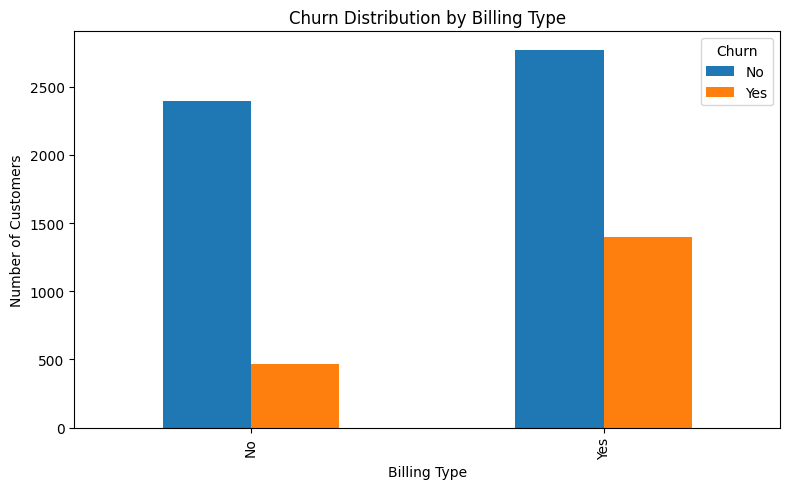

In [48]:
paper.plot(kind='bar', figsize=(8,5))
plt.xlabel('Billing Type')
plt.ylabel('Number of Customers')
plt.title('Churn Distribution by Billing Type')
plt.tight_layout()
plt.show()

### Impact of Paperless Billing on Churn

The analysis shows that customers using paperless billing (Paperless Billing) have a higher churn rate than those using paper billing.

The Chi² test confirms that the relationship between paperless billing and churn is statistically significant (p-value < 0.05).

Business Interpretation:

Customers using paperless billing may be more engaged in digital services and therefore more likely to compare competing offers. This can make it easier for them to decide to switch providers.

The company could analyze the behavior of customers using paperless billing in more detail to identify the specific reasons for their departure.

In [49]:
payement_method = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')
payement_method

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


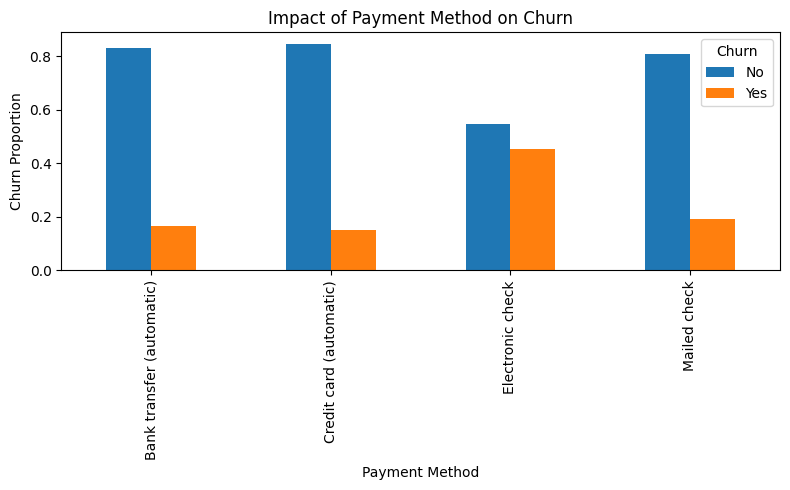

In [50]:
payement_method.plot(kind='bar', figsize=(8,5))
plt.xlabel('Payment Method')
plt.ylabel("Churn Proportion")
plt.title('Impact of Payment Method on Churn')
plt.tight_layout()
plt.show()

### Impact of Payment Method on Churn

The analysis shows that payment method is strongly associated with churn.

Customers using "Electronic Check" payments have the highest churn rate (about 45%), meaning nearly one in two customers leaves the service.

In contrast, automatic payment methods such as credit card or bank transfer have much lower churn rates.

Business Interpretation:

Automatic payments can strengthen customer loyalty by reducing payment-related friction, while customers using "Electronic Check" appear more likely to leave the platform.


In [51]:
paper_payement = pd.crosstab([df['PaperlessBilling'], df['PaymentMethod']], df['Churn'], normalize='index')
paper_payement

Churn                                             No       Yes
PaperlessBilling PaymentMethod                                
No               Bank transfer (automatic)  0.889740  0.110260
                 Credit card (automatic)    0.899844  0.100156
                 Electronic check           0.672552  0.327448
                 Mailed check               0.864067  0.135933
Yes              Bank transfer (automatic)  0.790776  0.209224
                 Credit card (automatic)    0.809524  0.190476
                 Electronic check           0.502296  0.497704
                 Mailed check               0.726718  0.273282

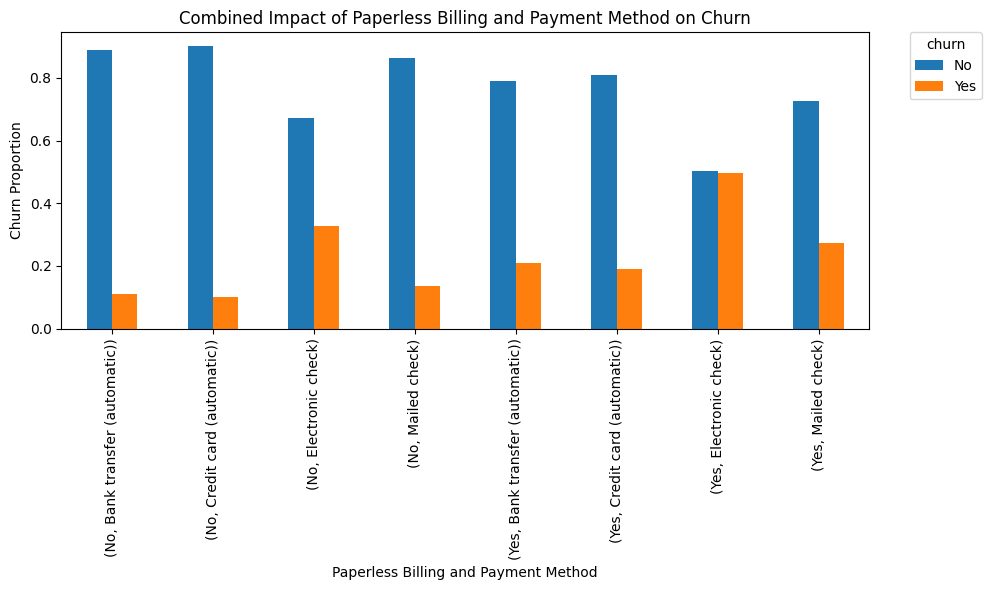

In [52]:
paper_payement.plot(kind='bar', figsize=(10,6))

plt.xlabel('Paperless Billing and Payment Method')
plt.ylabel('Churn Proportion')
plt.title('Combined Impact of Paperless Billing and Payment Method on Churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Combined Impact of Paperless Billing and Payment Method

The analysis shows that churn varies according to the combination of paperless billing (PaperlessBilling) and payment method.

Customers using "Electronic Check" payments have the highest churn rates, particularly when also using paperless billing, with a rate close to 50%.

In contrast, automatic payment methods such as bank transfer or credit card have much lower churn rates.

These results suggest that the combination of paperless billing and certain payment methods may be associated with a higher risk of customer departure.


In [53]:
streaming = pd.crosstab([df['StreamingMovies'], df['StreamingTV']], df['Churn'], normalize='index')
streaming

Churn                                          No       Yes
StreamingMovies     StreamingTV                            
No                  No                   0.655429  0.344571
                    Yes                  0.681937  0.318063
No internet service No internet service  0.925658  0.074342
Yes                 No                   0.688131  0.311869
                    Yes                  0.705518  0.294482

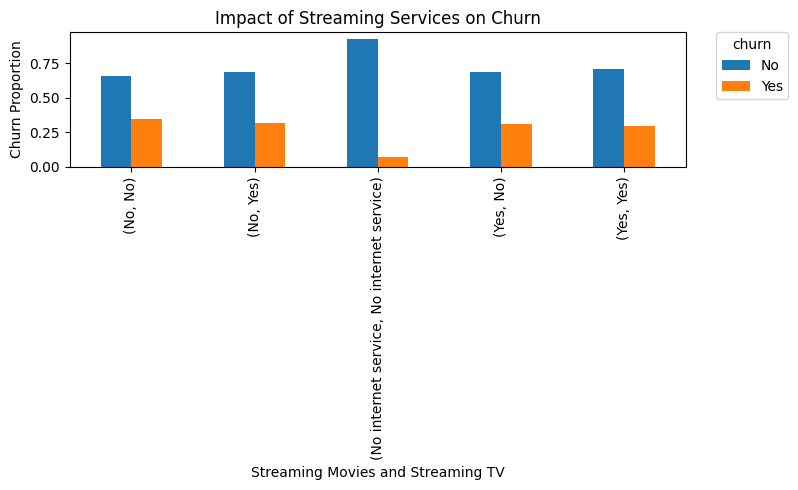

In [54]:
streaming.plot(kind='bar', figsize=(8,5))
plt.xlabel('Streaming Movies and Streaming TV')
plt.ylabel('Churn Proportion')
plt.title('Impact of Streaming Services on Churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Combined Impact of Streaming Services

The analysis shows that streaming services (StreamingMovies and StreamingTV) do not have a major impact on churn.

Churn rates remain relatively similar across different combinations of streaming services, with values ranging from about 29% to 34%.

In contrast, customers without internet service have a much lower churn rate.

These results suggest that streaming services are not a decisive factor in customers’ decision to leave the platform.


In [55]:
service = pd.crosstab([df['PhoneService'], df['InternetService']], df['Churn'], normalize='index')
service

Churn                               No       Yes
PhoneService InternetService                    
No           DSL              0.750000  0.250000
Yes          DSL              0.833525  0.166475
             Fiber optic      0.581072  0.418928
             No               0.925658  0.074342

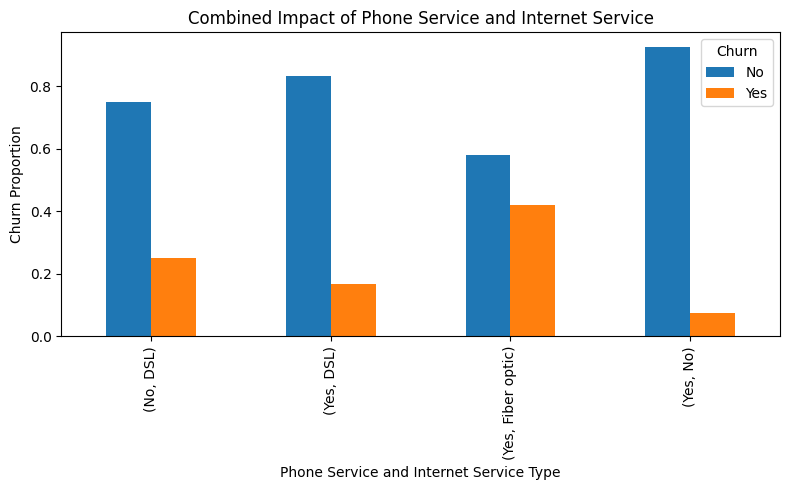

In [56]:
service.plot(kind='bar', figsize=(8,5))
plt.xlabel('Phone Service and Internet Service Type')
plt.ylabel('Churn Proportion')
plt.title('Combined Impact of Phone Service and Internet Service')
plt.tight_layout()
plt.show()

### Combined Impact of Phone Service and Internet Service

The analysis shows that the churn rate mainly varies according to the type of internet service used.

Customers using fiber optic have a much higher churn rate than those using DSL or having no internet service.

The presence of a phone service does not seem to have a major impact on churn.

These results suggest that the type of internet service is a much more decisive factor in customers’ decision to leave the platform.


In [57]:
contract_monthlycharge = pd.crosstab([df['MonthlyCharges_bins'], df['Contract']], df['Churn'], normalize='index')
contract_monthlycharge

Churn                                     No       Yes
MonthlyCharges_bins Contract                          
0-25                Month-to-month  0.786916  0.213084
                    One year        0.973761  0.026239
                    Two year        0.992110  0.007890
25-50               Month-to-month  0.615652  0.384348
                    One year        0.921875  0.078125
                    Two year        0.985000  0.015000
50-75               Month-to-month  0.610494  0.389506
                    One year        0.910864  0.089136
                    Two year        0.977528  0.022472
75-100              Month-to-month  0.467541  0.532459
                    One year        0.879452  0.120548
                    Two year        0.970443  0.029557
100-125             Month-to-month  0.500000  0.500000
                    One year        0.743682  0.256318
                    Two year        0.924590  0.075410

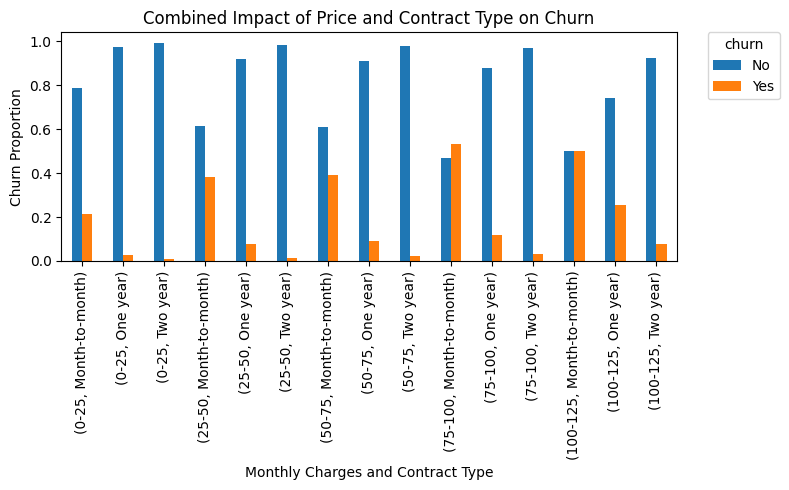

In [58]:
contract_monthlycharge.plot(kind='bar', figsize=(8,5))
plt.xlabel('Monthly Charges and Contract Type')
plt.ylabel('Churn Proportion')
plt.title('Combined Impact of Price and Contract Type on Churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Combined Impact of Monthly Charges and Contract Type

The analysis shows that churn is particularly high among customers with a month-to-month contract and high monthly charges.

For example, customers paying between 75 and 100 units with a month-to-month contract have a churn rate above 50%.

Conversely, customers with one- or two-year contracts have much lower churn rates, even when monthly charges are high.

Business Interpretation:

Monthly contracts offer greater flexibility to customers, making it easier for them to leave when prices rise or their expectations are not met.

Encouraging customers to subscribe to longer-term contracts could be an effective strategy to reduce churn.

In [59]:
charges = pd.crosstab([df['MonthlyCharges_bins'], df['PaymentMethod']], df['Churn'], normalize='index')
charges

Churn                                                No       Yes
MonthlyCharges_bins PaymentMethod                                
0-25                Bank transfer (automatic)  0.936842  0.063158
                    Credit card (automatic)    0.974820  0.025180
                    Electronic check           0.784000  0.216000
                    Mailed check               0.892396  0.107604
25-50               Bank transfer (automatic)  0.839080  0.160920
                    Credit card (automatic)    0.846154  0.153846
                    Electronic check           0.566667  0.433333
                    Mailed check               0.779783  0.220217
50-75               Bank transfer (automatic)  0.856734  0.143266
                    Credit card (automatic)    0.838527  0.161473
                    Electronic check           0.588889  0.411111
                    Mailed check               0.746667  0.253333
75-100              Bank transfer (automatic)  0.771488  0.228512
                    Credit card (automatic)    0.797071  0.202929
                    Electronic check           0.474383  0.525617
                    Mailed check               0.680952  0.319048
100-125             Bank transfer (automatic)  0.793774  0.206226
                    Credit card (automatic)    0.813043  0.186957
                    Electronic check           0.598404  0.401596
                    Mailed check               0.777778  0.222222

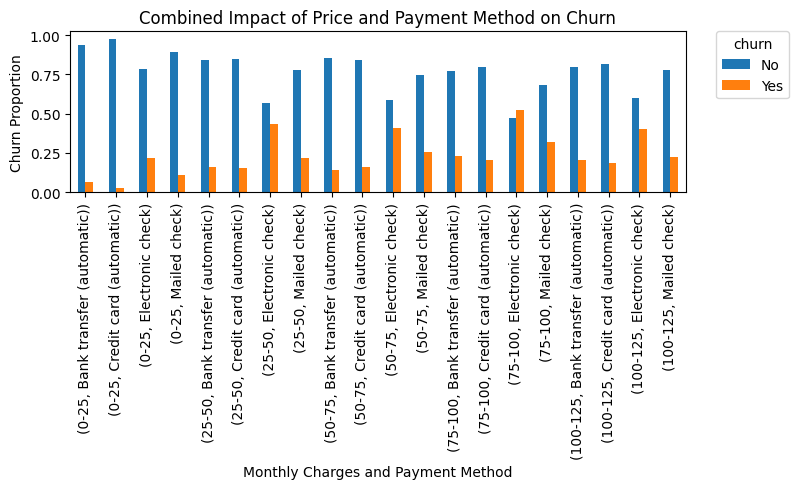

In [60]:
charges.plot(kind='bar', figsize=(8,5))
plt.xlabel('Monthly Charges and Payment Method')
plt.ylabel('Churn Proportion')
plt.title('Combined Impact of Price and Payment Method on Churn')
plt.legend(title='churn', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Combined Impact of Monthly Charges and Payment Method

The analysis shows that customers using "Electronic Check" payments have the highest churn rates across almost all monthly charge brackets.

This trend is particularly noticeable for customers with high monthly charges.

Conversely, customers using automatic payment methods such as credit card or bank transfer have lower churn rates.

Business Interpretation:

Automatic payment methods can promote a more stable relationship between the customer and the company. In contrast, customers using "Electronic Check" payments may be less engaged and more likely to leave the service.


## 2. Which Customer Segments Are Most Likely to Churn?

The analysis of different variables allows the identification of several customer segments that have a higher risk of churn.

## Customers with Month-to-Month Contracts

Customers with a "Month-to-month" contract have the highest churn rates.
Unlike one- or two-year contracts, this type of contract offers more flexibility and allows customers to leave the service more easily.

## Customers with Low Tenure

Customers with low tenure are more likely to leave the platform.
Churn is particularly high during the first months of subscription, indicating that the initial experiences with the service are critical.

## Senior Customers

SeniorCitizen customers have a higher churn rate than other customers.
About 42% of senior customers leave the service, compared to about 23% of non-senior customers.

## Customers with High Monthly Charges

Customers with high MonthlyCharges have a higher churn rate.
This may indicate that some customers consider the service too expensive relative to the perceived value.

## Customers Using Fiber Optic Internet

Customers using fiber optic show a higher churn rate than those using DSL or having no internet service.


## 3. How Long Are Customers Generally Active?

The tenure variable allows for analyzing the duration during which customers remain subscribed to the service.

The analysis shows that customers who leave the platform generally have low tenure. The churn rate is particularly high among customers with less than 10 months of tenure.

As tenure increases, the likelihood of churn gradually decreases. Customers with more than 50 or 60 months of tenure have a much lower churn rate.

This suggests that the first months of the customer relationship are the most critical. Customers who stay longer generally become more loyal and are less likely to leave the platform.


## 5. What Actions Can Improve Customer Retention?

Based on the analyses carried out, several actions can be implemented to reduce churn and improve customer retention.

## Encourage Long-Term Contracts

Customers with month-to-month contracts have the highest churn rates.
The company could encourage customers to choose one- or two-year contracts, for example by offering discounts or exclusive benefits.

## Improve the Experience of New Customers

The analysis of tenure shows that churn is higher among customers with low tenure.
The company could improve the experience of new customers by offering:

* better guidance during registration

* promotional offers during the first months

* enhanced customer support at the beginning of the subscription.

## Encourage Automatic Payments

Customers using Electronic Check have a higher churn rate than those using automatic payments.
The company could encourage automatic payments (credit card or bank transfer) by offering discounts or benefits.

## Reevaluate Offers for High-Charge Customers

Customers with high monthly charges show a higher churn rate.
The company could offer more competitive plans or service packages to improve the perceived value of the service.

### Improving Fiber Optic Customer Satisfaction
Customers using fiber optic have a higher churn rate. The company should analyze possible reasons, such as:
## Improving Fiber Optic Customer Satisfaction

Customers using fiber optic have a higher churn rate. The company should analyze possible reasons, such as:

* service quality

* value for money

* overall user satisfaction.

## Final Conclusion

This analysis aimed to understand the factors associated with customer churn in a telecommunications company. The study of different variables allowed the identification of several important trends.

The results show that churn is particularly high among customers with a monthly contract, low tenure, and those with high monthly charges. In addition, certain services like Fiber Optic and certain payment methods like Electronic Check are also associated with higher churn rates.

The analysis also revealed that certain customer segments, notably senior customers, have a higher likelihood of leaving the platform. In contrast, variables such as gender or certain streaming services seem to have little influence on churn.

These results help identify the most at-risk customer segments and guide retention strategies. Actions such as encouraging long-term contracts, improving the experience of new customers, or promoting automatic payments could contribute to reducing churn and improving customer retention.


